In [ ]:
%pip install -U pandas numpy matplotlib scikit-learn ipykernel
import tf_idf_observer as tid
import matplotlib.pyplot as plt
import pandas as pd




[notice] A new release of pip is available: 23.3.1 -> 26.1.1
[notice] To update, run: python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 4.6 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 23.3.1 -> 26.1.1
[notice] To update, run: python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import sys
print(sys.executable)

/opt/homebrew/opt/python@3.10/bin/python3.10


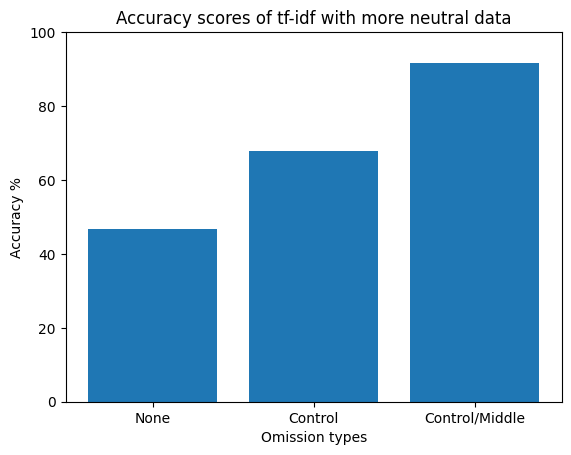

In [ ]:
accuracy_all_neutral, confusion_matrix_all_neutral = tid.tf_idf_accuracy('datasets/dataset_a_neutral.csv', False, False)
accuracy_noctrl_neutral, confusion_matrix_noctrl_neutral = tid.tf_idf_accuracy('datasets/dataset_a_neutral.csv', True, False)
accuracy_noctrl_middle_neutral, confusion_matrix_noctrl_middle_neutral = tid.tf_idf_accuracy('datasets/dataset_a_neutral.csv', True, True)
tests = ["None", "Control", "Control/Middle"]
scores = [accuracy_all_neutral*100, accuracy_noctrl_neutral*100, accuracy_noctrl_middle_neutral*100]
plt.bar(tests, scores)
plt.title("Accuracy scores of tf-idf with more neutral data")
plt.xlabel("Omission types")
plt.ylabel("Accuracy %")
plt.ylim(0, 100)
plt.show()

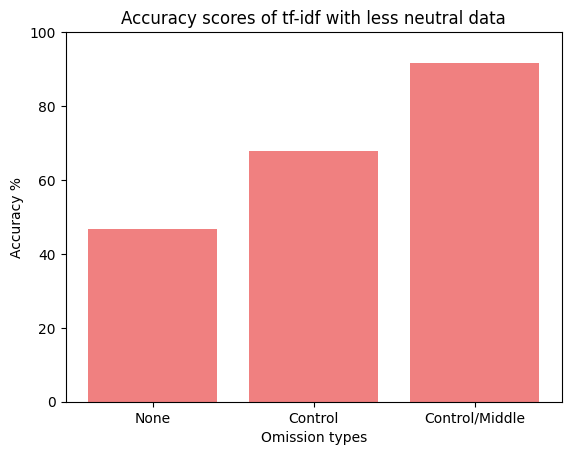

In [ ]:
accuracy_all_bias, confusion_matrix_all_bias = tid.tf_idf_accuracy('datasets/dataset_b_biased.csv', False, False)
accuracy_noctrl_bias, confusion_matrix_noctrl_bias = tid.tf_idf_accuracy('datasets/dataset_b_biased.csv', True, False)
accuracy_noctrl_middle_bias, confusion_matrix_noctrl_middle_bias = tid.tf_idf_accuracy('datasets/dataset_b_biased.csv', True, True)
tests = ["None", "Control", "Control/Middle"]
scores = [accuracy_all_bias*100, accuracy_noctrl_bias*100, accuracy_noctrl_middle_bias*100]
plt.bar(tests, scores, color='lightcoral')
plt.title("Accuracy scores of tf-idf with less neutral data")
plt.xlabel("Omission types")
plt.ylabel("Accuracy %")
plt.ylim(0, 100)
plt.show()

In [ ]:
llm_data_zshot = pd.read_csv('predictions/dataset_a_neutral_zero_shot_llm_observer.csv')
# llm_data_zshot = llm_data_zshot[llm_data_zshot['label'] != 0]
# llm_data_zshot = llm_data_zshot[llm_data_zshot['label'] != 2]

llm_labels_zshot = llm_data_zshot['label'].tolist()
llm_predictions_zshot = llm_data_zshot['prediction'].tolist()
correct_pred = 0

for i in range(len(llm_labels_zshot)):
    if(llm_labels_zshot[i] == llm_predictions_zshot[i]):
        correct_pred += 1

llm_accuracy_zshot = round(float(correct_pred)/float(len(llm_labels_zshot)), 4) * 100

print("LLM Accuracy: ", llm_accuracy_zshot, "%")


LLM Accuracy:  43.66 %


In [ ]:
llm_data_fshot = pd.read_csv('predictions/dataset_a_neutral_few_shot_llm_observer.csv')
# llm_data_fshot = llm_data_fshot[llm_data_fshot['label'] != 0]
# llm_data_fshot = llm_data_fshot[llm_data_fshot['label'] != 2]

llm_labels_fshot = llm_data_fshot['label'].tolist()
llm_predictions_fshot = llm_data_fshot['prediction'].tolist()
correct_pred = 0

for i in range(len(llm_labels_fshot)):
    if(llm_labels_fshot[i] == llm_predictions_fshot[i]):
        correct_pred += 1

llm_accuracy_fshot = round(float(correct_pred)/float(len(llm_labels_fshot)), 4) * 100

print("LLM Accuracy: ", llm_accuracy_fshot, "%")


LLM Accuracy:  53.99 %


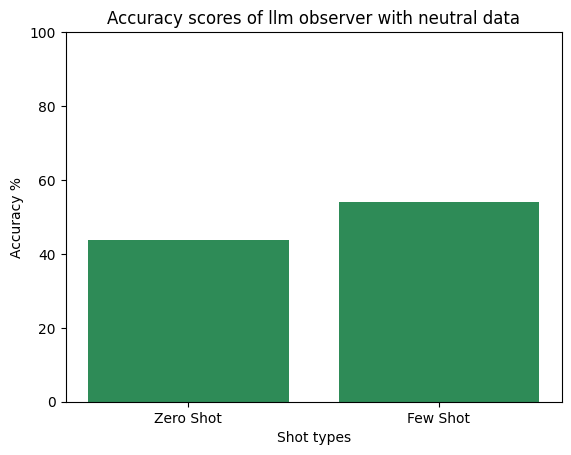

In [ ]:
shots = ["Zero Shot", "Few Shot"]
llm_scores = [llm_accuracy_zshot, llm_accuracy_fshot]
plt.bar(shots, llm_scores, color="seagreen")
plt.title("Accuracy scores of llm observer with neutral data")
plt.xlabel("Shot types")
plt.ylabel("Accuracy %")
plt.ylim(0, 100)
plt.show()

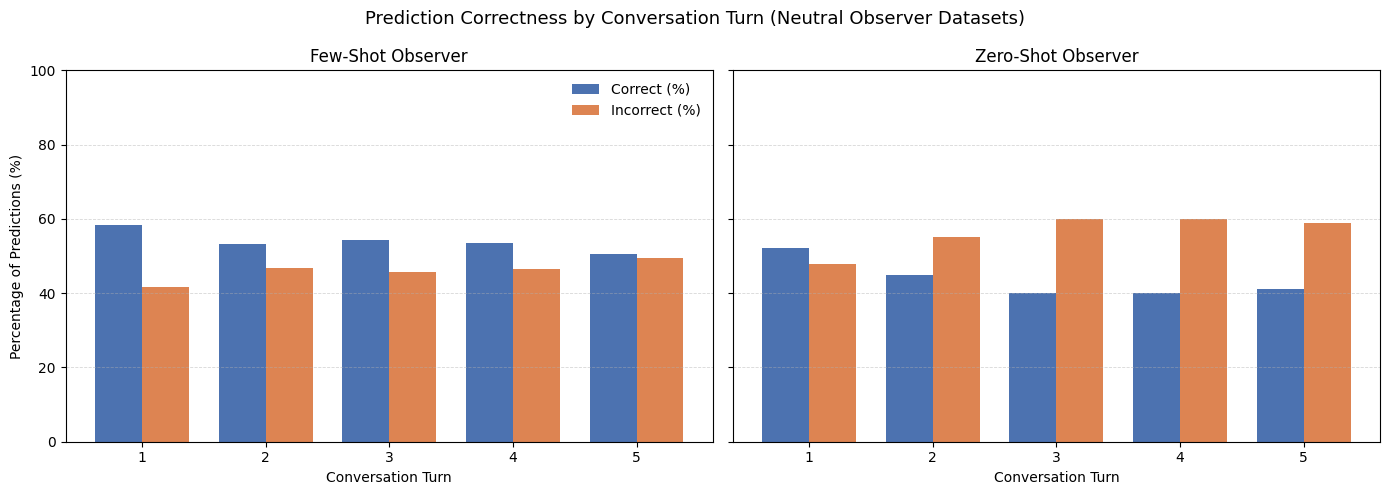

Few-shot per-turn summary:
   conversation_turn  total  correct  incorrect  correct_pct  incorrect_pct
0                  1    426      249        177        58.45          41.55
1                  2    426      227        199        53.29          46.71
2                  3    426      231        195        54.23          45.77
3                  4    426      228        198        53.52          46.48
4                  5    426      215        211        50.47          49.53

Zero-shot per-turn summary:
   conversation_turn  total  correct  incorrect  correct_pct  incorrect_pct
0                  1    426      222        204        52.11          47.89
1                  2    426      191        235        44.84          55.16
2                  3    426      171        255        40.14          59.86
3                  4    426      171        255        40.14          59.86
4                  5    426      175        251        41.08          58.92


In [ ]:
# Per-turn prediction quality: grouped bar charts for few-shot vs zero-shot observer datasets for dataset A
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

few_path = "predictions/dataset_a_neutral_few_shot_llm_observer.csv"
zero_path = "predictions/dataset_a_neutral_zero_shot_llm_observer.csv"

def per_turn_accuracy_breakdown(path):
    df = pd.read_csv(path)

    required_cols = {"conversation_turn", "label", "prediction"}
    missing = required_cols.difference(df.columns)
    if missing:
        raise ValueError(f"Missing required columns in {path}: {sorted(missing)}")

    grouped = (
        df.assign(is_correct=(df["label"] == df["prediction"]).astype(int))
          .groupby("conversation_turn", as_index=False)
          .agg(total=("is_correct", "size"), correct=("is_correct", "sum"))
          .sort_values("conversation_turn")
    )

    grouped["incorrect"] = grouped["total"] - grouped["correct"]
    grouped["correct_pct"] = (grouped["correct"] / grouped["total"]) * 100
    grouped["incorrect_pct"] = (grouped["incorrect"] / grouped["total"]) * 100

    return grouped

few_stats = per_turn_accuracy_breakdown(few_path)
zero_stats = per_turn_accuracy_breakdown(zero_path)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle("Prediction Correctness by Conversation Turn (Neutral Observer Datasets)", fontsize=13)

# Scientific/education-friendly tones
correct_color = "#4C72B0"   # muted blue
incorrect_color = "#DD8452" # muted orange

for ax, stats, title in [
    (axes[0], few_stats, "Few-Shot Observer"),
    (axes[1], zero_stats, "Zero-Shot Observer"),
]:
    turns = stats["conversation_turn"].to_numpy()
    x = np.arange(len(turns))
    width = 0.38

    ax.bar(x - width / 2, stats["correct_pct"], width, label="Correct (%)", color=correct_color)
    ax.bar(x + width / 2, stats["incorrect_pct"], width, label="Incorrect (%)", color=incorrect_color)

    ax.set_title(title)
    ax.set_xlabel("Conversation Turn")
    ax.set_xticks(x)
    ax.set_xticklabels(turns)
    ax.set_ylim(0, 100)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)

axes[0].set_ylabel("Percentage of Predictions (%)")
axes[0].legend(frameon=False)

plt.tight_layout()
plt.show()

print("Few-shot per-turn summary:")
print(few_stats[["conversation_turn", "total", "correct", "incorrect", "correct_pct", "incorrect_pct"]].round(2))
print("\nZero-shot per-turn summary:")
print(zero_stats[["conversation_turn", "total", "correct", "incorrect", "correct_pct", "incorrect_pct"]].round(2))

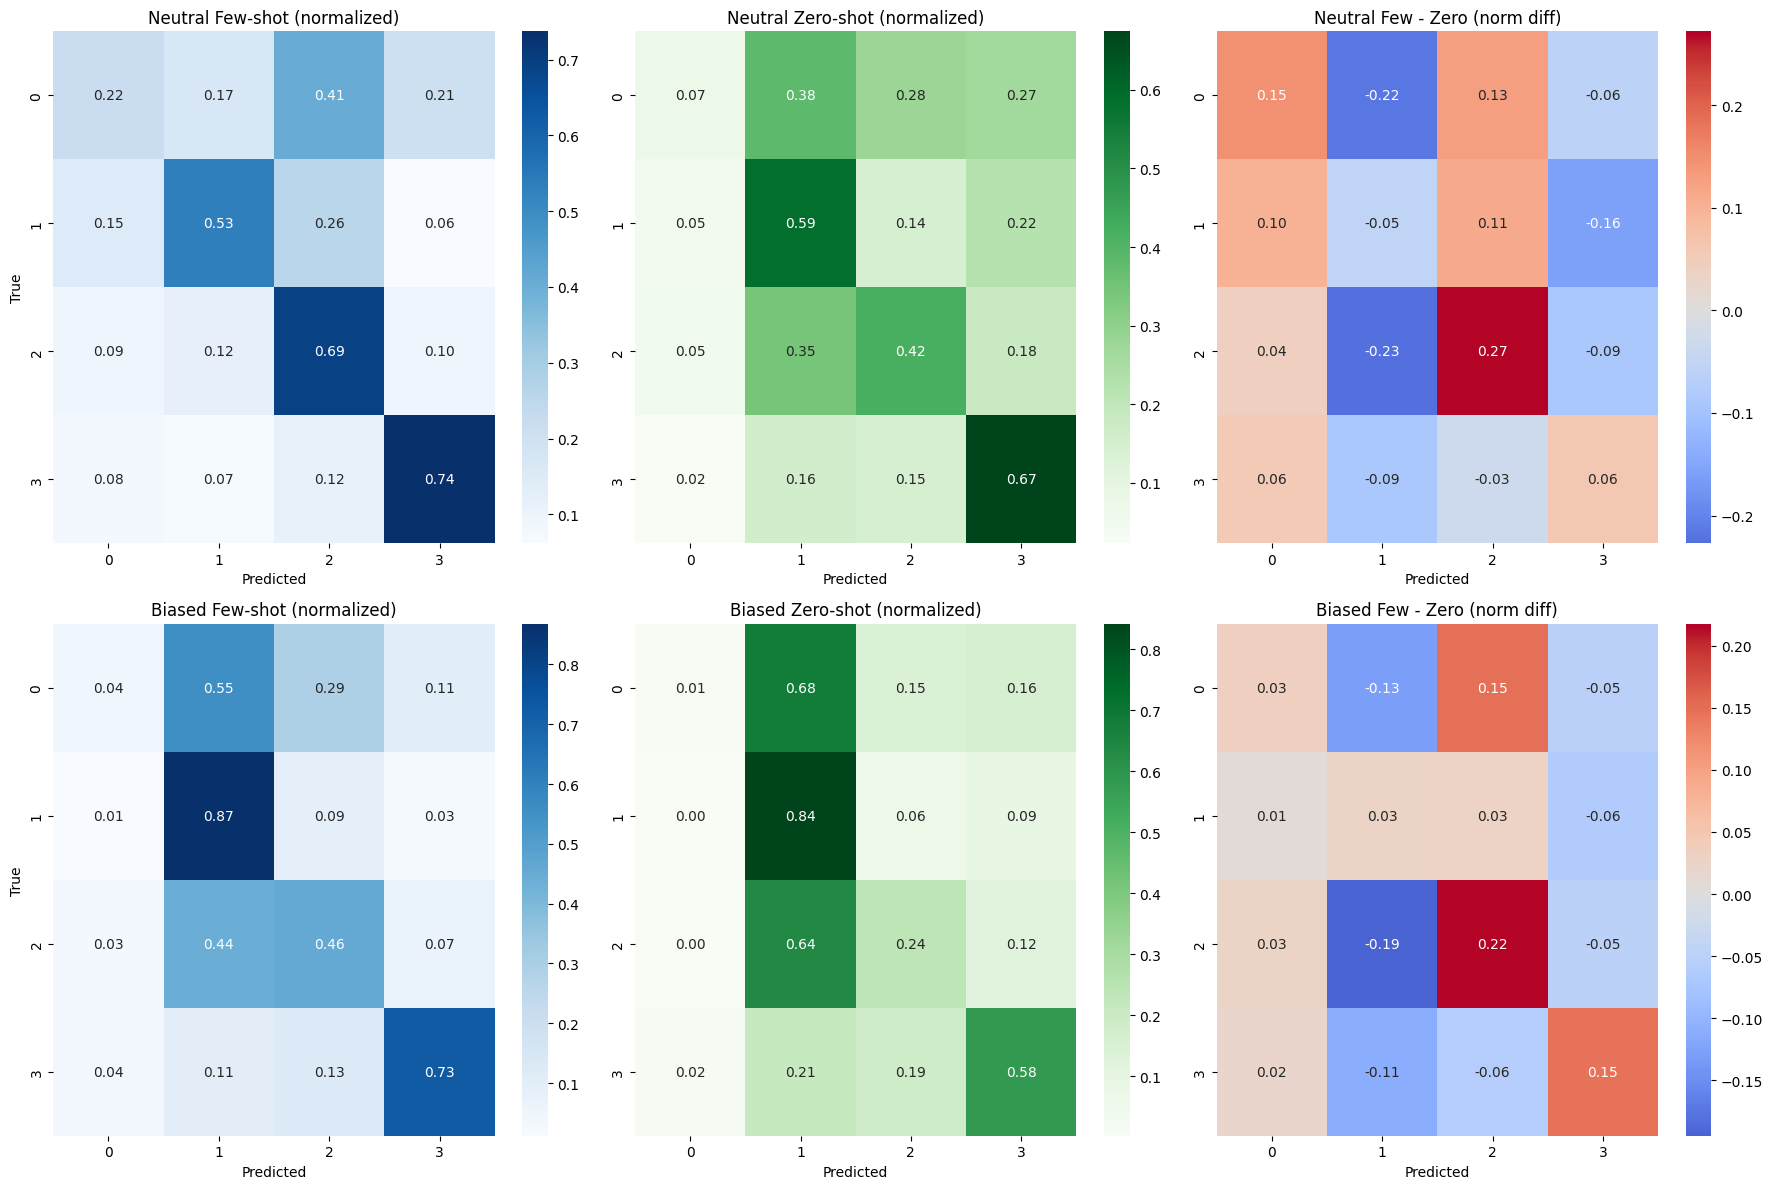


Neutral - Average normalized confusion by label distance (Few-shot):
 distance 1: few=0.173, zero=0.237
 distance 2: few=0.234, zero=0.250
 distance 3: few=0.206, zero=0.266

Biased - Average normalized confusion by label distance (Few-shot):
 distance 1: few=0.239, zero=0.290
 distance 2: few=0.161, zero=0.118
 distance 3: few=0.107, zero=0.160


In [10]:
# Confusion matrix comparison: Few-shot vs Zero-shot (Neutral and Biased)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

paths = {
    'Neutral': { 'few': 'predictions/dataset_a_neutral_few_shot_llm_observer.csv', 'zero': 'predictions/dataset_a_neutral_zero_shot_llm_observer.csv' },
    'Biased':  { 'few': 'predictions/dataset_b_biased_few_shot_llm_observer.csv',  'zero': 'predictions/dataset_b_biased_zero_shot_llm_observer.csv' },
}

def load_labels(path):
    df = pd.read_csv(path, index_col=None)
    if 'Unnamed: 0' in df.columns:
        df = df.loc[:, df.columns != 'Unnamed: 0']
    return df['label'].astype(int).to_numpy(), df['prediction'].astype(int).to_numpy()

def row_norm(cm):
    with np.errstate(divide='ignore', invalid='ignore'):
        rn = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    return np.nan_to_num(rn)

results = {}
all_labels = set()
for name, p in paths.items():
    y_f, p_f = load_labels(p['few'])
    y_z, p_z = load_labels(p['zero'])
    labels = np.unique(np.concatenate([np.unique(y_f), np.unique(y_z), np.unique(p_f), np.unique(p_z)]))
    labels = np.sort(labels)
    all_labels.update(labels.tolist())
    cm_f = confusion_matrix(y_f, p_f, labels=labels)
    cm_z = confusion_matrix(y_z, p_z, labels=labels)
    results[name] = {'labels': labels, 'cm_f': cm_f, 'cm_z': cm_z, 'cm_f_norm': row_norm(cm_f), 'cm_z_norm': row_norm(cm_z)}

# Plot: 2 rows (Neutral, Biased) x 3 cols (Few, Zero, Diff)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for r, name in enumerate(['Neutral','Biased']):
    res = results[name]
    labels = res['labels']
    sns.heatmap(res['cm_f_norm'], annot=True, fmt='.2f', ax=axes[r,0], xticklabels=labels, yticklabels=labels, cmap='Blues')
    axes[r,0].set_title(f'{name} Few-shot (normalized)')
    axes[r,0].set_xlabel('Predicted')
    axes[r,0].set_ylabel('True')

    sns.heatmap(res['cm_z_norm'], annot=True, fmt='.2f', ax=axes[r,1], xticklabels=labels, yticklabels=labels, cmap='Greens')
    axes[r,1].set_title(f'{name} Zero-shot (normalized)')
    axes[r,1].set_xlabel('Predicted')

    diff = res['cm_f_norm'] - res['cm_z_norm']
    sns.heatmap(diff, annot=True, fmt='.2f', ax=axes[r,2], xticklabels=labels, yticklabels=labels, cmap='coolwarm', center=0)
    axes[r,2].set_title(f'{name} Few - Zero (norm diff)')
    axes[r,2].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

# Ordinal-distance diagnostics: average confusion for distances 1..k
for name in ['Neutral','Biased']:
    res = results[name]
    labels = res['labels']
    cmf = res['cm_f_norm']
    cmz = res['cm_z_norm']
    print(f'\n{name} - Average normalized confusion by label distance (Few-shot):')
    n = len(labels)
    for d in range(1, n):
        vals_f = [cmf[i, i+d] for i in range(n-d)]
        vals_z = [cmz[i, i+d] for i in range(n-d)]
        print(f' distance {d}: few={np.mean(vals_f):.3f}, zero={np.mean(vals_z):.3f}')

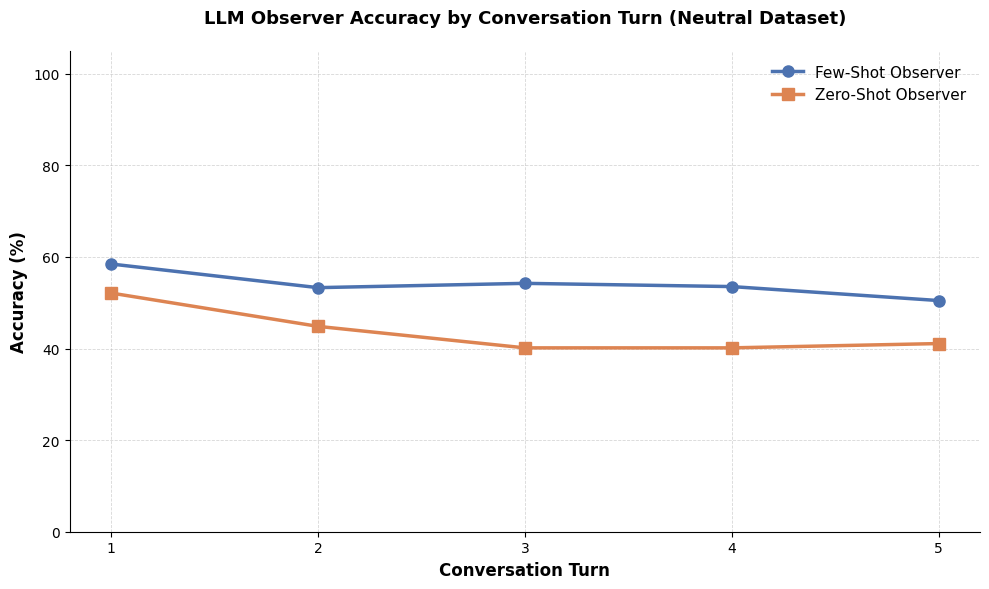

Accuracy Curve Summary (Neutral Dataset):

Few-Shot Observer:
  Mean Accuracy: 53.99%
  Min Accuracy: 50.47% (Turn 5)
  Max Accuracy: 58.45% (Turn 1)

Zero-Shot Observer:
  Mean Accuracy: 43.66%
  Min Accuracy: 40.14% (Turn 3)
  Max Accuracy: 52.11% (Turn 1)


In [ ]:
# Accuracy curve: few-shot vs zero-shot across conversation turns
import numpy as np
import matplotlib.pyplot as plt

# Extract accuracy curves from per-turn data
few_turns = few_stats["conversation_turn"].values
few_accuracy = few_stats["correct_pct"].values

zero_turns = zero_stats["conversation_turn"].values
zero_accuracy = zero_stats["correct_pct"].values

# Create figure with scientific styling
fig, ax = plt.subplots(figsize=(10, 6))

# Plot lines with markers
few_line = ax.plot(few_turns, few_accuracy, marker='o', linewidth=2.5, markersize=8, 
                   label='Few-Shot Observer', color='#4C72B0')
zero_line = ax.plot(zero_turns, zero_accuracy, marker='s', linewidth=2.5, markersize=8, 
                    label='Zero-Shot Observer', color='#DD8452')

# Styling
ax.set_xlabel('Conversation Turn', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('LLM Observer Accuracy by Conversation Turn (Neutral Dataset)', 
             fontsize=13, fontweight='bold', pad=20)

ax.set_xticks(few_turns)
ax.set_ylim(0, 105)
ax.grid(True, linestyle='--', linewidth=0.6, alpha=0.5)
ax.legend(frameon=False, fontsize=11, loc='best')

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Print summary statistics
print("Accuracy Curve Summary (Neutral Dataset):")
print(f"\nFew-Shot Observer:")
print(f"  Mean Accuracy: {few_accuracy.mean():.2f}%")
print(f"  Min Accuracy: {few_accuracy.min():.2f}% (Turn {few_turns[few_accuracy.argmin()]})")
print(f"  Max Accuracy: {few_accuracy.max():.2f}% (Turn {few_turns[few_accuracy.argmax()]})")
print(f"\nZero-Shot Observer:")
print(f"  Mean Accuracy: {zero_accuracy.mean():.2f}%")
print(f"  Min Accuracy: {zero_accuracy.min():.2f}% (Turn {zero_turns[zero_accuracy.argmin()]})")
print(f"  Max Accuracy: {zero_accuracy.max():.2f}% (Turn {zero_turns[zero_accuracy.argmax()]})")

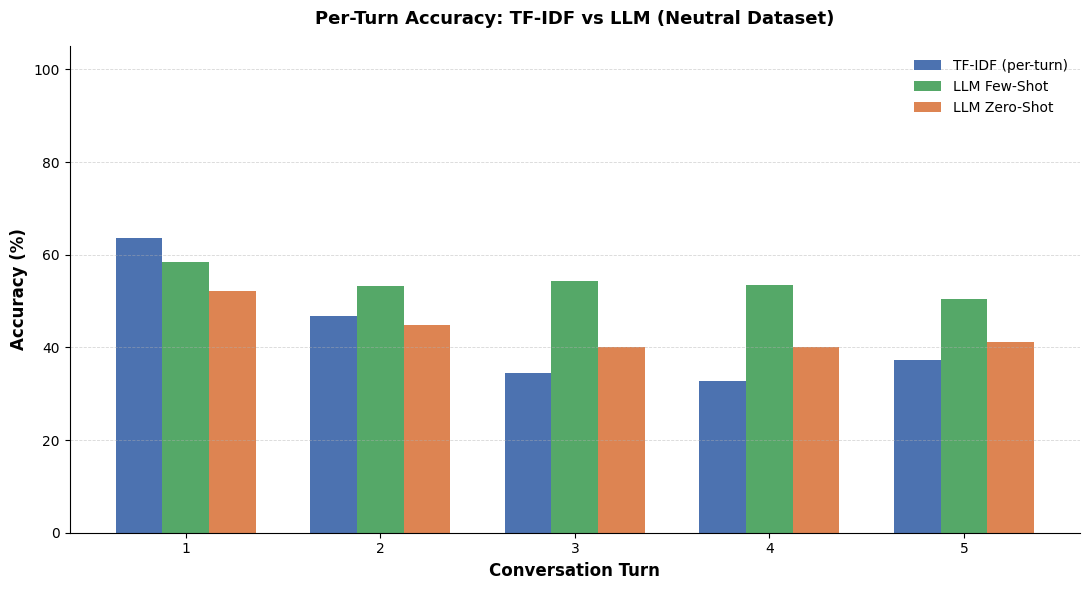


Per-turn accuracy comparison (percent):
 conversation_turn  tfidf_accuracy_pct  llm_fewshot_pct  llm_zeroshot_pct
                 1               63.55            58.45             52.11
                 2               46.73            53.29             44.84
                 3               34.58            54.23             40.14
                 4               32.71            53.52             40.14
                 5               37.38            50.47             41.08


In [ ]:
# Per-turn TF-IDF models and grouped comparison with LLM few/zero-shot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset and compute TF-IDF accuracy per conversation turn
dataset_path = 'datasets/dataset_a_neutral.csv'
df = pd.read_csv(dataset_path)

turns = [0,1,2,3,4]
tfidf_accuracies = []

for t in turns:
    col = f'llm_output_{t}'
    if col not in df.columns:
        raise ValueError(f"Column {col} not found in {dataset_path}")

    texts = df[col].astype(str).tolist()
    labels = df['trait_selected'].astype(str).tolist()

    X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.25, random_state=42)
    vec = TfidfVectorizer()
    X_train_tfidf = vec.fit_transform(X_train)
    X_test_tfidf = vec.transform(X_test)

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train_tfidf, y_train)
    preds = clf.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds) * 100
    tfidf_accuracies.append(acc)

# Compute per-turn LLM few-shot and zero-shot accuracies from prediction CSVs
def per_turn_correct_pct_from_csv(path):
    d = pd.read_csv(path)
    if {'conversation_turn', 'label', 'prediction'}.difference(d.columns):
        raise ValueError(f"Missing required columns in {path}")
    gp = (
        d.assign(is_correct=(d['label'] == d['prediction']).astype(int))
         .groupby('conversation_turn', as_index=False)
         .agg(total=('is_correct','size'), correct=('is_correct','sum'))
         .sort_values('conversation_turn')
    )
    gp['correct_pct'] = (gp['correct'] / gp['total']) * 100
    return gp

few_path = 'predictions/dataset_a_neutral_few_shot_llm_observer.csv'
zero_path = 'predictions/dataset_a_neutral_zero_shot_llm_observer.csv'

few_gp = per_turn_correct_pct_from_csv(few_path)
zero_gp = per_turn_correct_pct_from_csv(zero_path)

# Align turns (convert to 1-based display if needed)
display_turns = few_gp['conversation_turn'].to_numpy()
tfidf_display_acc = np.array(tfidf_accuracies)[:len(display_turns)]
few_display_acc = few_gp['correct_pct'].to_numpy()
zero_display_acc = zero_gp['correct_pct'].to_numpy()

# Grouped bar chart: TF-IDF vs Few-shot vs Zero-shot
x = np.arange(len(display_turns))
width = 0.24

fig, ax = plt.subplots(figsize=(11,6))
# Colors: TF-IDF blue, Few-shot muted green, Zero-shot muted orange
ax.bar(x - width, tfidf_display_acc, width, label='TF-IDF (per-turn)', color='#4C72B0')
ax.bar(x, few_display_acc, width, label='LLM Few-Shot', color='#55A868')
ax.bar(x + width, zero_display_acc, width, label='LLM Zero-Shot', color='#DD8452')

ax.set_xlabel('Conversation Turn', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Per-Turn Accuracy: TF-IDF vs LLM (Neutral Dataset)', fontsize=13, fontweight='bold', pad=16)
ax.set_xticks(x)
ax.set_xticklabels(display_turns)
ax.set_ylim(0, 105)
ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.5)
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Print table for quick inspection
summary_df = pd.DataFrame({
    'conversation_turn': display_turns,
    'tfidf_accuracy_pct': tfidf_display_acc.round(2),
    'llm_fewshot_pct': few_display_acc.round(2),
    'llm_zeroshot_pct': zero_display_acc.round(2)
})

print('\nPer-turn accuracy comparison (percent):')
print(summary_df.to_string(index=False))


In [ ]:
# Export all analysis charts to disk (best quality)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

out_dir = Path("analysis")
out_dir.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name_stem):
    pdf_path = out_dir / f"{name_stem}.pdf"
    png_path = out_dir / f"{name_stem}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=400, bbox_inches="tight")
    plt.close(fig)
    return str(pdf_path), str(png_path)

saved_files = []

# 1) TF-IDF neutral omission chart
tests = ["None", "Control", "Control/Middle"]
scores = [accuracy_all_neutral * 100, accuracy_noctrl_neutral * 100, accuracy_noctrl_middle_neutral * 100]
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(tests, scores, color="#4C72B0")
ax.set_title("Accuracy scores of tf-idf with more neutral data")
ax.set_xlabel("Omission types")
ax.set_ylabel("Accuracy %")
ax.set_ylim(0, 100)
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
saved_files.extend(save_fig(fig, "tfidf_neutral_omission_accuracy"))

# 2) TF-IDF biased omission chart
scores = [accuracy_all_bias * 100, accuracy_noctrl_bias * 100, accuracy_noctrl_middle_bias * 100]
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(tests, scores, color="#DD8452")
ax.set_title("Accuracy scores of tf-idf with less neutral data")
ax.set_xlabel("Omission types")
ax.set_ylabel("Accuracy %")
ax.set_ylim(0, 100)
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
saved_files.extend(save_fig(fig, "tfidf_biased_omission_accuracy"))

# 3) LLM overall shot comparison chart
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(["Zero Shot", "Few Shot"], [llm_accuracy_zshot, llm_accuracy_fshot], color="#55A868")
ax.set_title("Accuracy scores of llm observer with neutral data")
ax.set_xlabel("Shot types")
ax.set_ylabel("Accuracy %")
ax.set_ylim(0, 100)
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
saved_files.extend(save_fig(fig, "llm_overall_shot_accuracy"))

# 4) Grouped bars: correct vs incorrect per turn (few-shot and zero-shot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle("Prediction Correctness by Conversation Turn (Neutral Observer Datasets)", fontsize=13)

correct_color = "#4C72B0"
incorrect_color = "#DD8452"
for ax, stats, title in [
    (axes[0], few_stats, "Few-Shot Observer"),
    (axes[1], zero_stats, "Zero-Shot Observer"),
]:
    turns = stats["conversation_turn"].to_numpy()
    x = np.arange(len(turns))
    width = 0.38
    ax.bar(x - width / 2, stats["correct_pct"], width, label="Correct (%)", color=correct_color)
    ax.bar(x + width / 2, stats["incorrect_pct"], width, label="Incorrect (%)", color=incorrect_color)
    ax.set_title(title)
    ax.set_xlabel("Conversation Turn")
    ax.set_xticks(x)
    ax.set_xticklabels(turns)
    ax.set_ylim(0, 100)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
axes[0].set_ylabel("Percentage of Predictions (%)")
axes[0].legend(frameon=False)
saved_files.extend(save_fig(fig, "llm_per_turn_correct_incorrect_grouped"))

# 5) Line chart: few-shot vs zero-shot by turn
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(few_stats["conversation_turn"].values, few_stats["correct_pct"].values, marker="o", linewidth=2.5,
        markersize=8, label="Few-Shot Observer", color="#4C72B0")
ax.plot(zero_stats["conversation_turn"].values, zero_stats["correct_pct"].values, marker="s", linewidth=2.5,
        markersize=8, label="Zero-Shot Observer", color="#DD8452")
ax.set_xlabel("Conversation Turn", fontsize=12, fontweight="bold")
ax.set_ylabel("Accuracy (%)", fontsize=12, fontweight="bold")
ax.set_title("LLM Observer Accuracy by Conversation Turn (Neutral Dataset)", fontsize=13, fontweight="bold", pad=20)
ax.set_xticks(few_stats["conversation_turn"].values)
ax.set_ylim(0, 105)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
ax.legend(frameon=False, fontsize=11, loc="best")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
saved_files.extend(save_fig(fig, "llm_per_turn_accuracy_curve"))

# 6) Grouped bars: TF-IDF per-turn vs LLM few-shot vs LLM zero-shot
dataset_path = "datasets/dataset_a_neutral.csv"
df = pd.read_csv(dataset_path)

turns = [0, 1, 2, 3, 4]
tfidf_accuracies = []
for t in turns:
    col = f"llm_output_{t}"
    texts = df[col].astype(str).tolist()
    labels = df["trait_selected"].astype(str).tolist()
    X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.25, random_state=42)
    vec = TfidfVectorizer()
    X_train_tfidf = vec.fit_transform(X_train)
    X_test_tfidf = vec.transform(X_test)
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train_tfidf, y_train)
    preds = clf.predict(X_test_tfidf)
    tfidf_accuracies.append(accuracy_score(y_test, preds) * 100)

display_turns = few_stats["conversation_turn"].to_numpy()
tfidf_display_acc = np.array(tfidf_accuracies)[:len(display_turns)]
few_display_acc = few_stats["correct_pct"].to_numpy()
zero_display_acc = zero_stats["correct_pct"].to_numpy()

x = np.arange(len(display_turns))
width = 0.24
fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - width, tfidf_display_acc, width, label="TF-IDF (per-turn)", color="#4C72B0")
ax.bar(x, few_display_acc, width, label="LLM Few-Shot", color="#55A868")
ax.bar(x + width, zero_display_acc, width, label="LLM Zero-Shot", color="#DD8452")
ax.set_xlabel("Conversation Turn", fontsize=12, fontweight="bold")
ax.set_ylabel("Accuracy (%)", fontsize=12, fontweight="bold")
ax.set_title("Per-Turn Accuracy: TF-IDF vs LLM (Neutral Dataset)", fontsize=13, fontweight="bold", pad=16)
ax.set_xticks(x)
ax.set_xticklabels(display_turns)
ax.set_ylim(0, 105)
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
saved_files.extend(save_fig(fig, "tfidf_vs_llm_per_turn_grouped"))

print("Saved chart files:")
for p in saved_files:
    print("-", p)

print("\nRecommended for best quality: PDF for papers/slides; PNG (400 dpi) for raster uses.")

Saved chart files:
- analysis/tfidf_neutral_omission_accuracy.pdf
- analysis/tfidf_neutral_omission_accuracy.png
- analysis/tfidf_biased_omission_accuracy.pdf
- analysis/tfidf_biased_omission_accuracy.png
- analysis/llm_overall_shot_accuracy.pdf
- analysis/llm_overall_shot_accuracy.png
- analysis/llm_per_turn_correct_incorrect_grouped.pdf
- analysis/llm_per_turn_correct_incorrect_grouped.png
- analysis/llm_per_turn_accuracy_curve.pdf
- analysis/llm_per_turn_accuracy_curve.png
- analysis/tfidf_vs_llm_per_turn_grouped.pdf
- analysis/tfidf_vs_llm_per_turn_grouped.png

Recommended for best quality: PDF for papers/slides; PNG (400 dpi) for raster uses.



Adjacency diagnostic (row-equal averages):
dataset  mean_adj_few  mean_adj_zero  diff_adj_few_minus_zero  mean_nonadj_few  mean_nonadj_zero  diff_nonadj_few_minus_zero  mean_absdist_few  mean_absdist_zero  diff_absdist_few_minus_zero
Neutral        0.2261         0.3128                  -0.0867           0.2284            0.2489                     -0.0204            0.7542             0.8828                      -0.1286
 Biased        0.3250         0.4242                  -0.0992           0.1509            0.1579                     -0.0069            0.6635             0.7842                      -0.1206


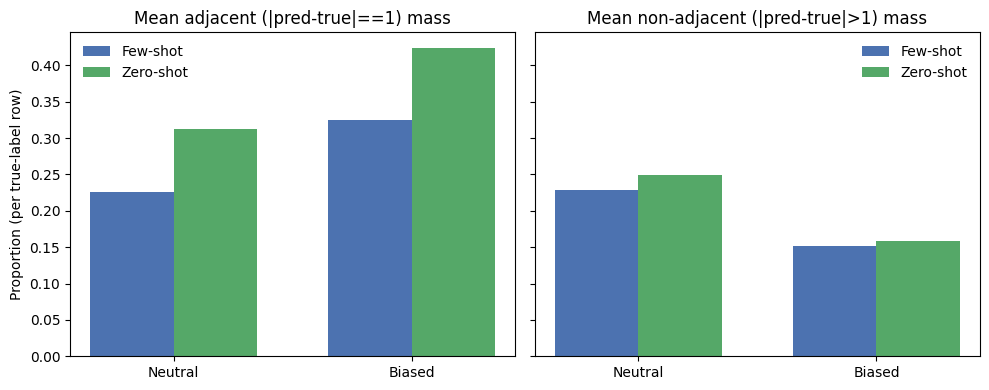


Neutral — adjacent mass: few=0.226, zero=0.313 (few - zero = -0.087)
Neutral — mean absolute label distance: few=0.754, zero=0.883 (few - zero = -0.129)
  -> Zero-shot shows more adjacent confusion.

Biased — adjacent mass: few=0.325, zero=0.424 (few - zero = -0.099)
Biased — mean absolute label distance: few=0.664, zero=0.784 (few - zero = -0.121)
  -> Zero-shot shows more adjacent confusion.


In [12]:
# Ordinal / adjacency diagnostics: are adjacent sensitivity levels harder to distinguish?
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

paths = {
    'Neutral': { 'few': 'predictions/dataset_a_neutral_few_shot_llm_observer.csv', 'zero': 'predictions/dataset_a_neutral_zero_shot_llm_observer.csv' },
    'Biased':  { 'few': 'predictions/dataset_b_biased_few_shot_llm_observer.csv',  'zero': 'predictions/dataset_b_biased_zero_shot_llm_observer.csv' },
}

def load_labels(path):
    df = pd.read_csv(path, index_col=None)
    if 'Unnamed: 0' in df.columns:
        df = df.loc[:, df.columns != 'Unnamed: 0']
    return df['label'].astype(int).to_numpy(), df['prediction'].astype(int).to_numpy()

def row_norm(cm):
    with np.errstate(divide='ignore', invalid='ignore'):
        rn = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    return np.nan_to_num(rn)

results = {}
for name, p in paths.items():
    y_f, p_f = load_labels(p['few'])
    y_z, p_z = load_labels(p['zero'])
    labels = np.unique(np.concatenate([np.unique(y_f), np.unique(y_z), np.unique(p_f), np.unique(p_z)]))
    labels = np.sort(labels)
    cm_f = confusion_matrix(y_f, p_f, labels=labels)
    cm_z = confusion_matrix(y_z, p_z, labels=labels)
    results[name] = {'labels': labels, 'cm_f': cm_f, 'cm_z': cm_z, 'cm_f_norm': row_norm(cm_f), 'cm_z_norm': row_norm(cm_z)}

summary_rows = []
for name, res in results.items():
    labels = res['labels']
    n = len(labels)
    cmf = res['cm_f_norm']
    cmz = res['cm_z_norm']

    # adjacency masks based on label numeric distance == 1
    label_vals = labels
    # For each true-label row index i, compute adjacency mass
    adj_mass_f_per_row = []
    adj_mass_z_per_row = []
    nonadj_mass_f_per_row = []
    nonadj_mass_z_per_row = []
    absdist_f_per_row = []
    absdist_z_per_row = []

    for i, lv in enumerate(label_vals):
        dists = np.abs(label_vals - lv)
        adj_mask = (dists == 1)
        nonadj_mask = (dists > 1)
        adj_mass_f_per_row.append(cmf[i, adj_mask].sum())
        adj_mass_z_per_row.append(cmz[i, adj_mask].sum())
        nonadj_mass_f_per_row.append(cmf[i, nonadj_mask].sum())
        nonadj_mass_z_per_row.append(cmz[i, nonadj_mask].sum())
        absdist_f_per_row.append((cmf[i] * dists).sum())
        absdist_z_per_row.append((cmz[i] * dists).sum())

    # Row-equal averages (treat each true label equally)
    mean_adj_f = float(np.mean(adj_mass_f_per_row))
    mean_adj_z = float(np.mean(adj_mass_z_per_row))
    mean_nonadj_f = float(np.mean(nonadj_mass_f_per_row))
    mean_nonadj_z = float(np.mean(nonadj_mass_z_per_row))
    mean_absdist_f = float(np.mean(absdist_f_per_row))
    mean_absdist_z = float(np.mean(absdist_z_per_row))

    # Differences (few - zero)
    diff_adj = mean_adj_f - mean_adj_z
    diff_nonadj = mean_nonadj_f - mean_nonadj_z
    diff_absdist = mean_absdist_f - mean_absdist_z

    summary_rows.append({
        'dataset': name,
        'mean_adj_few': mean_adj_f,
        'mean_adj_zero': mean_adj_z,
        'diff_adj_few_minus_zero': diff_adj,
        'mean_nonadj_few': mean_nonadj_f,
        'mean_nonadj_zero': mean_nonadj_z,
        'diff_nonadj_few_minus_zero': diff_nonadj,
        'mean_absdist_few': mean_absdist_f,
        'mean_absdist_zero': mean_absdist_z,
        'diff_absdist_few_minus_zero': diff_absdist,
    })

import pandas as _pd
summary_df = _pd.DataFrame(summary_rows)

print('\nAdjacency diagnostic (row-equal averages):')
print(summary_df.to_string(index=False, float_format='%.4f'))

# Quick bar plot: adjacent vs non-adjacent mass for each dataset and shot
fig, ax = plt.subplots(1, 2, figsize=(10,4), sharey=True)
x = np.arange(len(summary_df))
width = 0.35
ax[0].bar(x - width/2, summary_df['mean_adj_few'], width, label='Few-shot', color='#4C72B0')
ax[0].bar(x + width/2, summary_df['mean_adj_zero'], width, label='Zero-shot', color='#55A868')
ax[0].set_xticks(x); ax[0].set_xticklabels(summary_df['dataset'])
ax[0].set_title('Mean adjacent (|pred-true|==1) mass')
ax[0].set_ylabel('Proportion (per true-label row)')
ax[0].legend(frameon=False)

ax[1].bar(x - width/2, summary_df['mean_nonadj_few'], width, label='Few-shot', color='#4C72B0')
ax[1].bar(x + width/2, summary_df['mean_nonadj_zero'], width, label='Zero-shot', color='#55A868')
ax[1].set_xticks(x); ax[1].set_xticklabels(summary_df['dataset'])
ax[1].set_title('Mean non-adjacent (|pred-true|>1) mass')
ax[1].legend(frameon=False)

plt.tight_layout()
plt.show()

# Plain-language takeaway hints
for _, row in summary_df.iterrows():
    ds = row['dataset']
    adj_f = row['mean_adj_few']
    adj_z = row['mean_adj_zero']
    absd_f = row['mean_absdist_few']
    absd_z = row['mean_absdist_zero']
    print(f"\n{ds} — adjacent mass: few={adj_f:.3f}, zero={adj_z:.3f} (few - zero = {adj_f - adj_z:+.3f})")
    print(f"{ds} — mean absolute label distance: few={absd_f:.3f}, zero={absd_z:.3f} (few - zero = {absd_f - absd_z:+.3f})")
    if adj_f > adj_z:
        print(f"  -> Few-shot shows more adjacent confusion (may be swapping neighboring levels).")
    elif adj_f < adj_z:
        print(f"  -> Zero-shot shows more adjacent confusion.")
    else:
        print(f"  -> Adjacent confusion similar for both shots.")



Neutral confusion matrix - Few-shot (counts):
     0    1    2    3
0  113   87  209  106
1   94  336  161   39
2   52   66  384   53
3   34   29   50  317

Neutral confusion matrix - Zero-shot (counts):
    0    1    2    3
0  37  198  143  137
1  30  370   90  140
2  28  192  233  102
3  10   67   63  290

Biased confusion matrix - Few-shot (counts):
    0    1    2    3
0  30  371  197   72
1   9  651   69   21
2  22  326  339   53
3  27   72   89  497

Biased confusion matrix - Zero-shot (counts):
    0    1    2    3
0   7  458   98  107
1   3  631   48   68
2   2  470  178   90
3  12  147  129  397


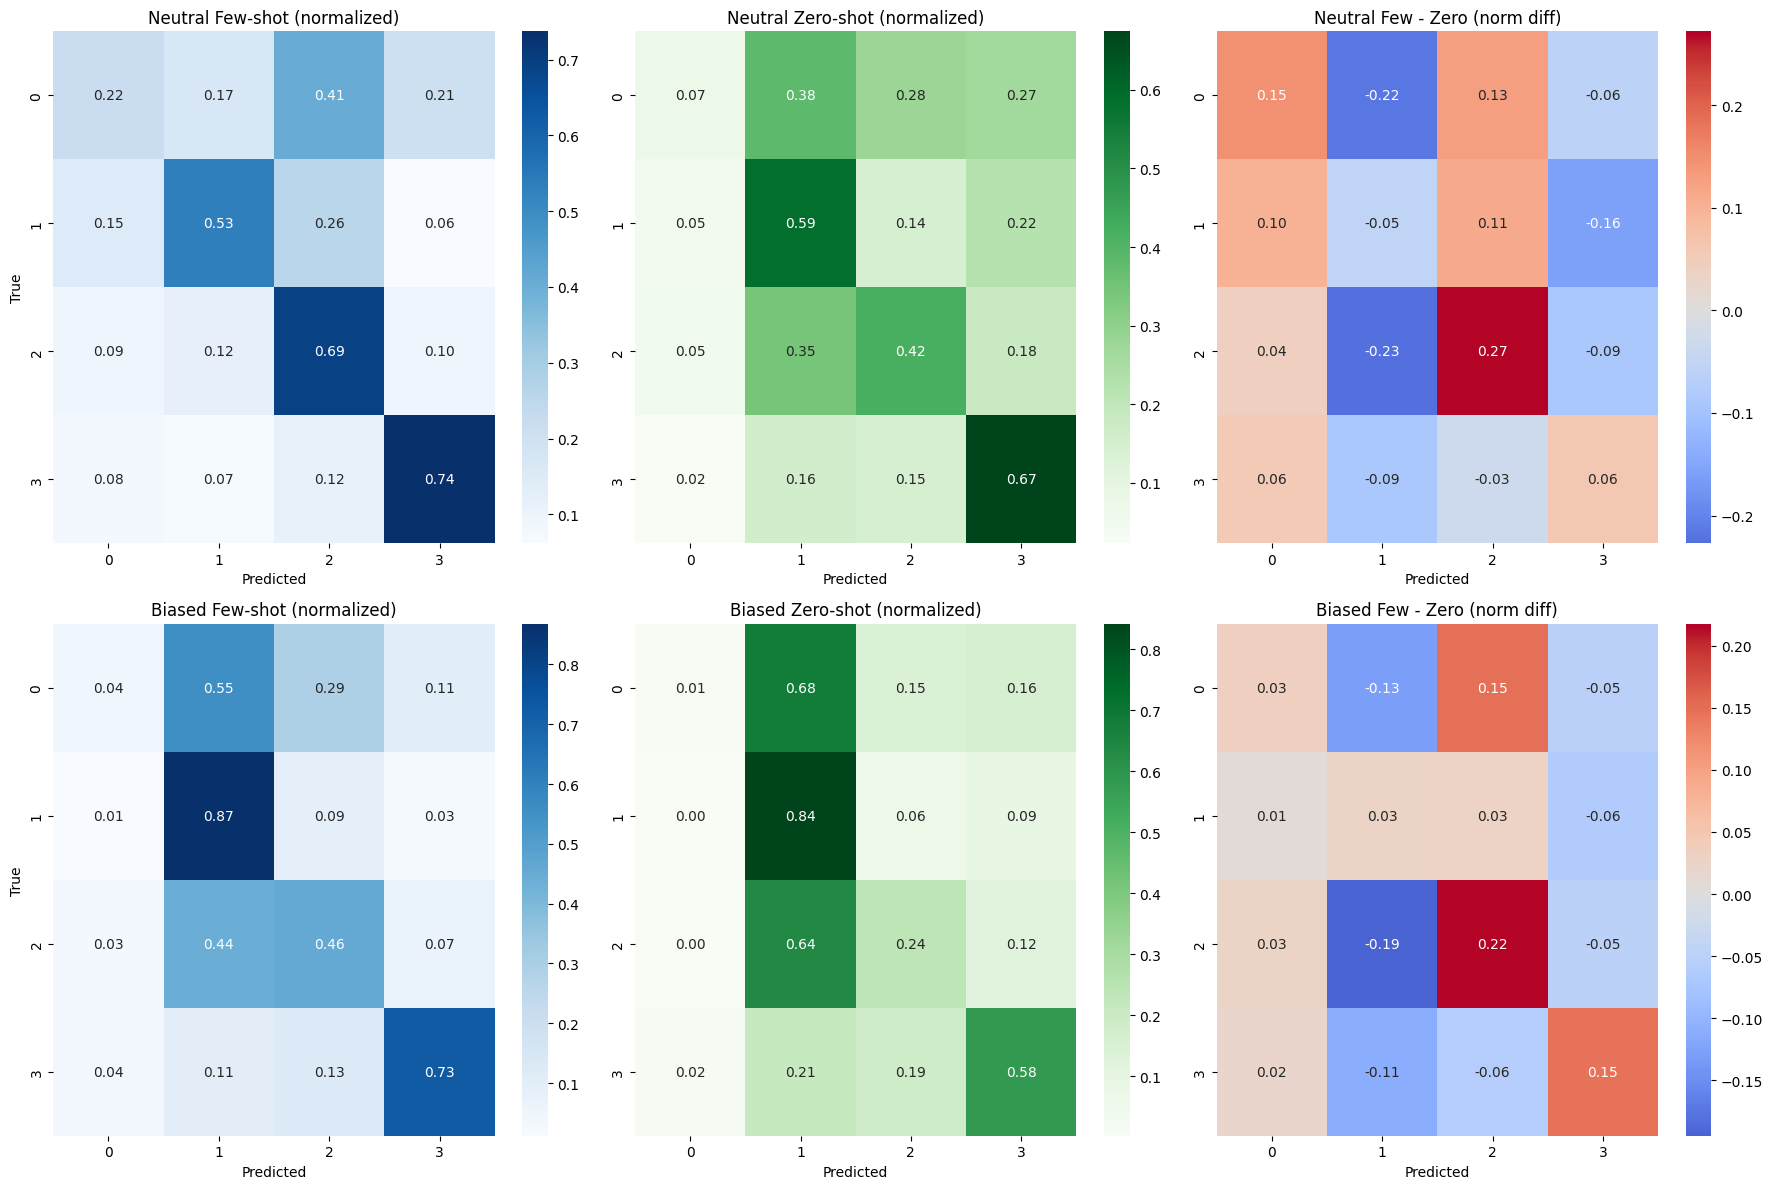

In [13]:
# Confusion matrices and heatmaps for Neutral vs Biased, Few-shot vs Zero-shot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

paths = {
    'Neutral': {
        'few': 'predictions/dataset_a_neutral_few_shot_llm_observer.csv',
        'zero': 'predictions/dataset_a_neutral_zero_shot_llm_observer.csv',
    },
    'Biased': {
        'few': 'predictions/dataset_b_biased_few_shot_llm_observer.csv',
        'zero': 'predictions/dataset_b_biased_zero_shot_llm_observer.csv',
    },
}

def load_labels(path):
    df = pd.read_csv(path, index_col=None)
    if 'Unnamed: 0' in df.columns:
        df = df.loc[:, df.columns != 'Unnamed: 0']
    return df['label'].astype(int).to_numpy(), df['prediction'].astype(int).to_numpy()

def row_norm(cm):
    with np.errstate(divide='ignore', invalid='ignore'):
        normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    return np.nan_to_num(normalized)

results = {}
for name, group_paths in paths.items():
    y_few, p_few = load_labels(group_paths['few'])
    y_zero, p_zero = load_labels(group_paths['zero'])
    labels = np.sort(np.unique(np.concatenate([y_few, y_zero, p_few, p_zero])))
    cm_few = confusion_matrix(y_few, p_few, labels=labels)
    cm_zero = confusion_matrix(y_zero, p_zero, labels=labels)
    results[name] = {
        'labels': labels,
        'cm_few': cm_few,
        'cm_zero': cm_zero,
        'cm_few_norm': row_norm(cm_few),
        'cm_zero_norm': row_norm(cm_zero),
    }

for name, res in results.items():
    labels = res['labels']
    print(f'\n{name} confusion matrix - Few-shot (counts):')
    print(pd.DataFrame(res['cm_few'], index=labels, columns=labels))
    print(f'\n{name} confusion matrix - Zero-shot (counts):')
    print(pd.DataFrame(res['cm_zero'], index=labels, columns=labels))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for row_idx, name in enumerate(['Neutral', 'Biased']):
    res = results[name]
    labels = res['labels']

    sns.heatmap(res['cm_few_norm'], annot=True, fmt='.2f', cmap='Blues', ax=axes[row_idx, 0], xticklabels=labels, yticklabels=labels)
    axes[row_idx, 0].set_title(f'{name} Few-shot (normalized)')
    axes[row_idx, 0].set_xlabel('Predicted')
    axes[row_idx, 0].set_ylabel('True')

    sns.heatmap(res['cm_zero_norm'], annot=True, fmt='.2f', cmap='Greens', ax=axes[row_idx, 1], xticklabels=labels, yticklabels=labels)
    axes[row_idx, 1].set_title(f'{name} Zero-shot (normalized)')
    axes[row_idx, 1].set_xlabel('Predicted')

    diff = res['cm_few_norm'] - res['cm_zero_norm']
    sns.heatmap(diff, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[row_idx, 2], xticklabels=labels, yticklabels=labels)
    axes[row_idx, 2].set_title(f'{name} Few - Zero (norm diff)')
    axes[row_idx, 2].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

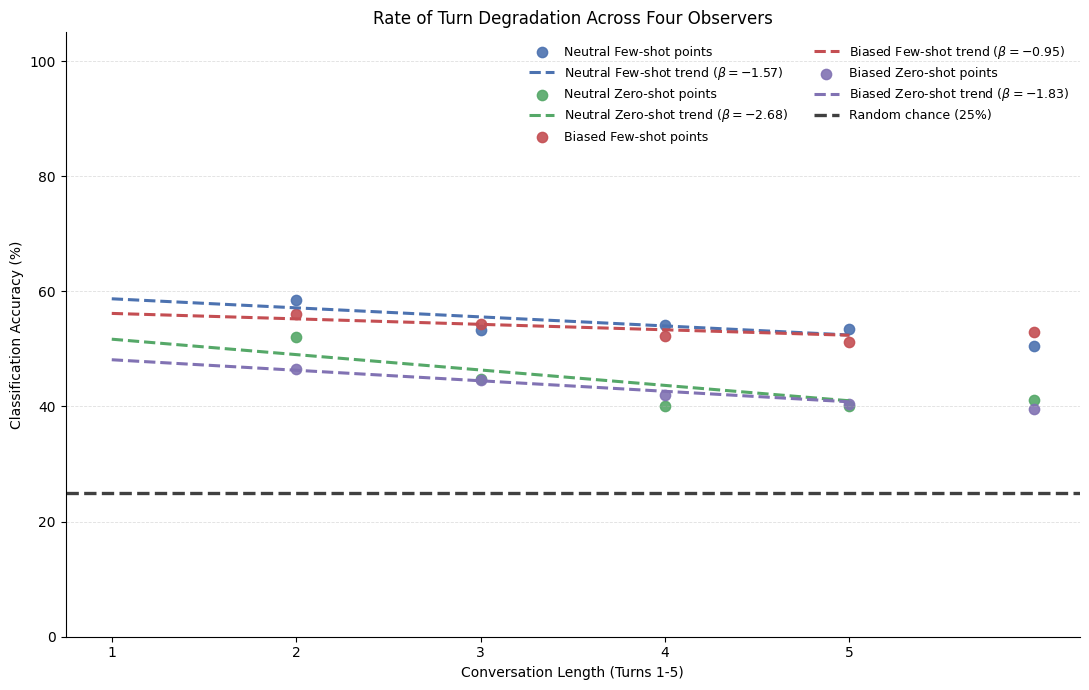

Linear regression slopes (beta) by observer:
  Neutral Few-shot: beta=-1.573 accuracy-points/turn
  Neutral Zero-shot: beta=-2.676 accuracy-points/turn
  Biased Few-shot: beta=-0.949 accuracy-points/turn
  Biased Zero-shot: beta=-1.828 accuracy-points/turn


In [14]:
# Linear regression rate of turn degradation: scatter points + trendlines for four observers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

observer_paths = {
    'Neutral Few-shot': 'predictions/dataset_a_neutral_few_shot_llm_observer.csv',
    'Neutral Zero-shot': 'predictions/dataset_a_neutral_zero_shot_llm_observer.csv',
    'Biased Few-shot': 'predictions/dataset_b_biased_few_shot_llm_observer.csv',
    'Biased Zero-shot': 'predictions/dataset_b_biased_zero_shot_llm_observer.csv',
}

def turnwise_accuracy(path):
    df = pd.read_csv(path)
    if {'conversation_turn', 'label', 'prediction'}.difference(df.columns):
        raise ValueError(f'Missing required columns in {path}')
    gp = (
        df.assign(is_correct=(df['label'] == df['prediction']).astype(int))
          .groupby('conversation_turn', as_index=False)
          .agg(total=('is_correct', 'size'), correct=('is_correct', 'sum'))
          .sort_values('conversation_turn')
    )
    gp['accuracy_pct'] = (gp['correct'] / gp['total']) * 100
    return gp

turn_curves = {name: turnwise_accuracy(path) for name, path in observer_paths.items()}

colors = {
    'Neutral Few-shot': '#4C72B0',
    'Neutral Zero-shot': '#55A868',
    'Biased Few-shot': '#C44E52',
    'Biased Zero-shot': '#8172B3',
}

fig, ax = plt.subplots(figsize=(11, 7))
x_line = np.arange(1, 6)

for name, curve in turn_curves.items():
    x = curve['conversation_turn'].to_numpy() + 1
    y = curve['accuracy_pct'].to_numpy()
    slope, intercept = np.polyfit(x, y, 1)
    y_hat = slope * x_line + intercept

    ax.scatter(x, y, s=55, color=colors[name], alpha=0.9, label=f'{name} points')
    ax.plot(x_line, y_hat, linestyle='--', linewidth=2.2, color=colors[name],
            label=f'{name} trend ($\\beta={slope:.2f}$)')

ax.axhline(25, linestyle='--', linewidth=2.4, color='black', alpha=0.75, label='Random chance (25%)')

ax.set_xlabel('Conversation Length (Turns 1-5)')
ax.set_ylabel('Classification Accuracy (%)')
ax.set_title('Rate of Turn Degradation Across Four Observers')
ax.set_xticks(x_line)
ax.set_ylim(0, 105)
ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, ncol=2, fontsize=9)

plt.tight_layout()
plt.show()

print('Linear regression slopes (beta) by observer:')
for name, curve in turn_curves.items():
    x = curve['conversation_turn'].to_numpy() + 1
    y = curve['accuracy_pct'].to_numpy()
    slope, intercept = np.polyfit(x, y, 1)
    print(f'  {name}: beta={slope:.3f} accuracy-points/turn')


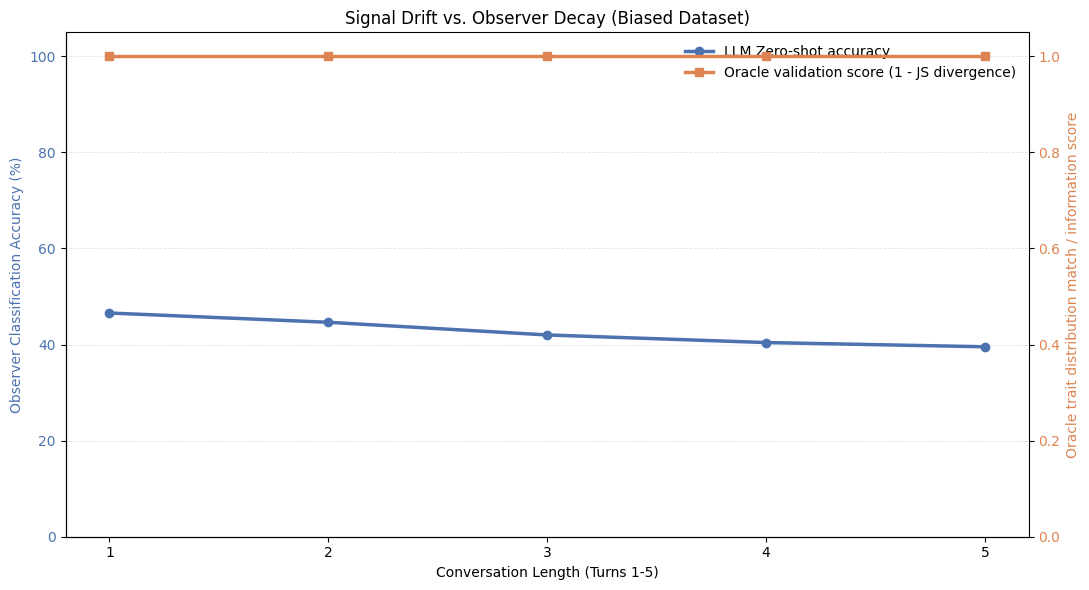

Per-turn zero-shot accuracy and oracle validation scores:
 conversation_turn  accuracy_pct  match_score  entropy_score
                 1       46.5729          1.0         0.9992
                 2       44.6397          1.0         0.9992
                 3       42.0035          1.0         0.9992
                 4       40.4218          1.0         0.9992
                 5       39.5431          1.0         0.9992

Note: the oracle curve is a validation proxy based on the per-turn label distribution matching the overall dataset label distribution.


In [17]:
# Signal drift vs observer decay: zero-shot accuracy against oracle validation score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

zero_path = 'predictions/dataset_b_biased_zero_shot_llm_observer.csv'

def turnwise_accuracy(path):
    df = pd.read_csv(path)
    if {'conversation_turn', 'label', 'prediction'}.difference(df.columns):
        raise ValueError(f'Missing required columns in {path}')
    gp = (
        df.assign(is_correct=(df['label'] == df['prediction']).astype(int))
          .groupby('conversation_turn', as_index=False)
          .agg(total=('is_correct', 'size'), correct=('is_correct', 'sum'))
          .sort_values('conversation_turn')
    )
    gp['accuracy_pct'] = (gp['correct'] / gp['total']) * 100
    return gp

def js_divergence(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    p = p / p.sum()
    q = q / q.sum()
    m = 0.5 * (p + q)
    def kl(a, b):
        mask = a > 0
        return np.sum(a[mask] * np.log2(a[mask] / b[mask]))
    return 0.5 * kl(p, m) + 0.5 * kl(q, m)

def oracle_validation_curve(csv_path):
    df = pd.read_csv(csv_path)
    if {'conversation_turn', 'label'}.difference(df.columns):
        raise ValueError(f'Missing required columns in {csv_path}')

    label_values = np.sort(df['label'].dropna().unique())
    global_counts = df['label'].value_counts().reindex(label_values, fill_value=0).to_numpy(dtype=float)
    if global_counts.sum() == 0:
        raise ValueError('Global label distribution is empty')
    global_dist = global_counts / global_counts.sum()

    rows = []
    max_entropy = float(np.log2(len(label_values))) if len(label_values) > 1 else 1.0
    for turn, group in df.groupby('conversation_turn', sort=True):
        turn_counts = group['label'].value_counts().reindex(label_values, fill_value=0).to_numpy(dtype=float)
        turn_dist = turn_counts / turn_counts.sum() if turn_counts.sum() else np.zeros_like(turn_counts)
        positive = turn_dist > 0
        entropy = float(-np.sum(turn_dist[positive] * np.log2(turn_dist[positive]))) if positive.any() else 0.0
        entropy_norm = entropy / max_entropy if max_entropy > 0 else 0.0
        match_score = 1.0 - js_divergence(turn_dist, global_dist)
        rows.append({
            'conversation_turn': turn,
            'match_score': match_score,
            'entropy_score': entropy_norm,
        })

    return pd.DataFrame(rows).sort_values('conversation_turn')

zero_curve = turnwise_accuracy(zero_path)
oracle_curve = oracle_validation_curve(zero_path)

fig, ax1 = plt.subplots(figsize=(11, 6))
x = zero_curve['conversation_turn'].to_numpy()

ax1.plot(x, zero_curve['accuracy_pct'].to_numpy(), marker='o', linewidth=2.5, color='#4C72B0',
         label='LLM Zero-shot accuracy')
ax1.set_xlabel('Conversation Length (Turns 1-5)')
ax1.set_ylabel('Observer Classification Accuracy (%)', color='#4C72B0')
ax1.tick_params(axis='y', labelcolor='#4C72B0')
ax1.set_xticks(x)
ax1.set_ylim(0, 105)
ax1.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.35)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2 = ax1.twinx()
ax2.plot(oracle_curve['conversation_turn'].to_numpy(), oracle_curve['match_score'].to_numpy(), marker='s', linewidth=2.5,
         color='#DD8452', label='Oracle validation score (1 - JS divergence)')
ax2.set_ylabel('Oracle trait distribution match / information score', color='#DD8452')
ax2.tick_params(axis='y', labelcolor='#DD8452')
ax2.set_ylim(0, 1.05)

ax1.set_title('Signal Drift vs. Observer Decay (Biased Dataset)')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, frameon=False, loc='best')

plt.tight_layout()
plt.show()

print('Per-turn zero-shot accuracy and oracle validation scores:')
merged = zero_curve[['conversation_turn', 'accuracy_pct']].merge(oracle_curve, on='conversation_turn', how='inner')
print(merged.round(4).to_string(index=False))
print('')
print('Note: the oracle curve is a validation proxy based on the per-turn label distribution matching the overall dataset label distribution.')


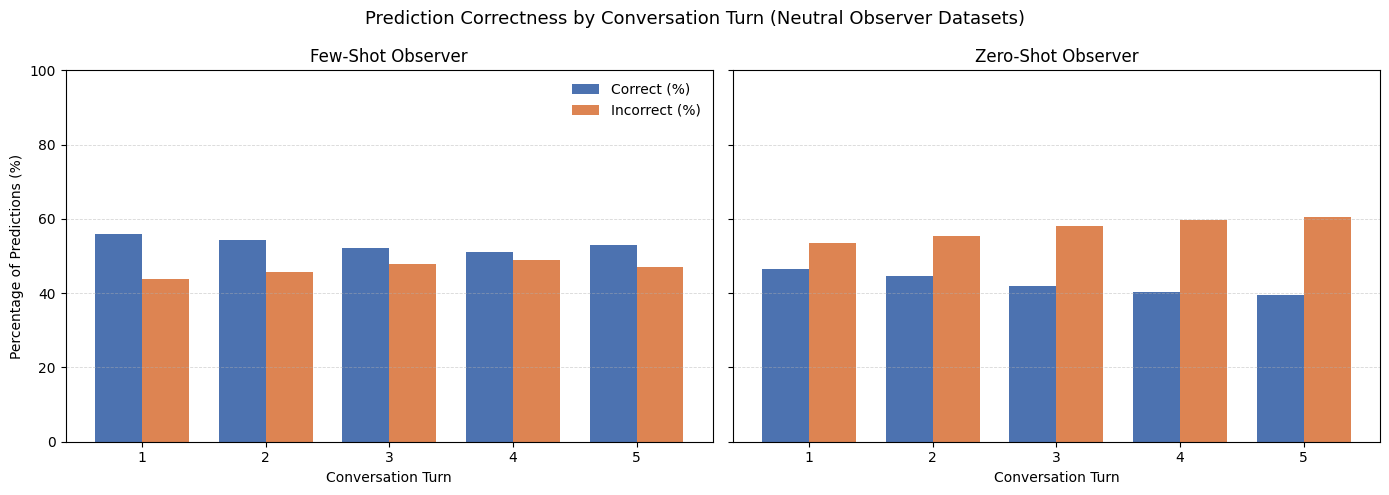

Few-shot per-turn summary:
   conversation_turn  total  correct  incorrect  correct_pct  incorrect_pct
0                  1    569      319        250        56.06          43.94
1                  2    569      309        260        54.31          45.69
2                  3    569      297        272        52.20          47.80
3                  4    569      291        278        51.14          48.86
4                  5    569      301        268        52.90          47.10

Zero-shot per-turn summary:
   conversation_turn  total  correct  incorrect  correct_pct  incorrect_pct
0                  1    569      265        304        46.57          53.43
1                  2    569      254        315        44.64          55.36
2                  3    569      239        330        42.00          58.00
3                  4    569      230        339        40.42          59.58
4                  5    569      225        344        39.54          60.46


In [18]:
# Per-turn prediction quality: grouped bar charts for few-shot vs zero-shot observer datasets for dataset B
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

few_path = "predictions/dataset_b_biased_few_shot_llm_observer.csv"
zero_path = "predictions/dataset_b_biased_zero_shot_llm_observer.csv"

def per_turn_accuracy_breakdown(path):
    df = pd.read_csv(path)

    required_cols = {"conversation_turn", "label", "prediction"}
    missing = required_cols.difference(df.columns)
    if missing:
        raise ValueError(f"Missing required columns in {path}: {sorted(missing)}")

    grouped = (
        df.assign(is_correct=(df["label"] == df["prediction"]).astype(int))
          .groupby("conversation_turn", as_index=False)
          .agg(total=("is_correct", "size"), correct=("is_correct", "sum"))
          .sort_values("conversation_turn")
    )

    grouped["incorrect"] = grouped["total"] - grouped["correct"]
    grouped["correct_pct"] = (grouped["correct"] / grouped["total"]) * 100
    grouped["incorrect_pct"] = (grouped["incorrect"] / grouped["total"]) * 100

    return grouped

few_stats = per_turn_accuracy_breakdown(few_path)
zero_stats = per_turn_accuracy_breakdown(zero_path)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle("Prediction Correctness by Conversation Turn (Neutral Observer Datasets)", fontsize=13)

# Scientific/education-friendly tones
correct_color = "#4C72B0"   # muted blue
incorrect_color = "#DD8452" # muted orange

for ax, stats, title in [
    (axes[0], few_stats, "Few-Shot Observer"),
    (axes[1], zero_stats, "Zero-Shot Observer"),
]:
    turns = stats["conversation_turn"].to_numpy()
    x = np.arange(len(turns))
    width = 0.38

    ax.bar(x - width / 2, stats["correct_pct"], width, label="Correct (%)", color=correct_color)
    ax.bar(x + width / 2, stats["incorrect_pct"], width, label="Incorrect (%)", color=incorrect_color)

    ax.set_title(title)
    ax.set_xlabel("Conversation Turn")
    ax.set_xticks(x)
    ax.set_xticklabels(turns)
    ax.set_ylim(0, 100)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)

axes[0].set_ylabel("Percentage of Predictions (%)")
axes[0].legend(frameon=False)

plt.tight_layout()
plt.show()

print("Few-shot per-turn summary:")
print(few_stats[["conversation_turn", "total", "correct", "incorrect", "correct_pct", "incorrect_pct"]].round(2))
print("\nZero-shot per-turn summary:")
print(zero_stats[["conversation_turn", "total", "correct", "incorrect", "correct_pct", "incorrect_pct"]].round(2))

In [ ]:
# Biased-only: Confusion heatmaps (Few-shot vs Zero-shot)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

few_path = 'predictions/dataset_b_biased_few_shot_llm_observer.csv'
zero_path = 'predictions/dataset_b_biased_zero_shot_llm_observer.csv'

def load_labels(path):
    df = pd.read_csv(path, index_col=None)
    if 'Unnamed: 0' in df.columns:
        df = df.loc[:, df.columns != 'Unnamed: 0']
    return df['label'].astype(int).to_numpy(), df['prediction'].astype(int).to_numpy()

def row_norm(cm):
    with np.errstate(divide='ignore', invalid='ignore'):
        rn = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    return np.nan_to_num(rn)

y_f, p_f = load_labels(few_path)
y_z, p_z = load_labels(zero_path)
labels = np.sort(np.unique(np.concatenate([y_f, y_z, p_f, p_z])))
cm_f = confusion_matrix(y_f, p_f, labels=labels)
cm_z = confusion_matrix(y_z, p_z, labels=labels)
cm_f_n = row_norm(cm_f)
cm_z_n = row_norm(cm_z)
diff = cm_f_n - cm_z_n

print('Biased - Few-shot confusion (counts):')
print(pd.DataFrame(cm_f, index=labels, columns=labels))
print('
Biased - Zero-shot confusion (counts):')
print(pd.DataFrame(cm_z, index=labels, columns=labels))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.heatmap(cm_f_n, annot=True, fmt='.2f', cmap='Blues', ax=axes[0], xticklabels=labels, yticklabels=labels)
axes[0].set_title('Biased Few-shot (normalized)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_z_n, annot=True, fmt='.2f', cmap='Greens', ax=axes[1], xticklabels=labels, yticklabels=labels)
axes[1].set_title('Biased Zero-shot (normalized)')
axes[1].set_xlabel('Predicted')

sns.heatmap(diff, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[2], xticklabels=labels, yticklabels=labels)
axes[2].set_title('Biased Few - Zero (norm diff)')
axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [ ]:
# Biased-only: Linear regression (turn degradation) and oracle dual-axis (Few vs Zero)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

observer_paths = {
    'Biased Few-shot': 'predictions/dataset_b_biased_few_shot_llm_observer.csv',
    'Biased Zero-shot': 'predictions/dataset_b_biased_zero_shot_llm_observer.csv',
}
def turnwise_accuracy(path):
    df = pd.read_csv(path)
    req = {'conversation_turn','label','prediction'}
    if not req.issubset(set(df.columns)):
        raise ValueError(f'Missing required columns in {path}')
    gp = (
        df.assign(is_correct=(df['label'] == df['prediction']).astype(int))
          .groupby('conversation_turn', as_index=False)
          .agg(total=('is_correct','size'), correct=('is_correct','sum'))
          .sort_values('conversation_turn')
    )
    gp['accuracy_pct'] = (gp['correct'] / gp['total']) * 100
    return gp

def js_divergence(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    p = p / p.sum()
    q = q / q.sum()
    m = 0.5 * (p + q)
    def kl(a, b):
        mask = a > 0
        return np.sum(a[mask] * np.log2(a[mask] / b[mask]))
    return 0.5 * kl(p, m) + 0.5 * kl(q, m)

def oracle_validation_curve(csv_path):
    d = pd.read_csv(csv_path)
    req = {'conversation_turn','label'}
    if not req.issubset(set(d.columns)):
        raise ValueError(f'Missing required columns in {csv_path}')
    label_values = np.sort(d['label'].dropna().unique())
    global_counts = d['label'].value_counts().reindex(label_values, fill_value=0).to_numpy(dtype=float)
    global_dist = global_counts / global_counts.sum()
    rows = []
    max_entropy = float(np.log2(len(label_values))) if len(label_values) > 1 else 1.0
    for turn, group in d.groupby('conversation_turn', sort=True):
        turn_counts = group['label'].value_counts().reindex(label_values, fill_value=0).to_numpy(dtype=float)
        turn_dist = turn_counts / turn_counts.sum() if turn_counts.sum() else np.zeros_like(turn_counts)
        positive = turn_dist > 0
        entropy = float(-np.sum(turn_dist[positive] * np.log2(turn_dist[positive]))) if positive.any() else 0.0
        entropy_norm = entropy / max_entropy if max_entropy > 0 else 0.0
        match_score = 1.0 - js_divergence(turn_dist, global_dist)
        rows.append({'conversation_turn': turn, 'match_score': match_score, 'entropy_score': entropy_norm})
    return pd.DataFrame(rows).sort_values('conversation_turn')

# Compute curves for both observers
curves = {name: turnwise_accuracy(p) for name, p in observer_paths.items()}
oracles = {name: oracle_validation_curve(p) for name, p in observer_paths.items()}

# Linear regression plot
fig, ax = plt.subplots(figsize=(10,6))
x_line = np.arange(1, 6)
colors = {'Biased Few-shot': '#C44E52', 'Biased Zero-shot': '#8172B3'}
for name, curve in curves.items():
    x = curve['conversation_turn'].to_numpy() + 1
    y = curve['accuracy_pct'].to_numpy()
    slope, intercept = np.polyfit(x, y, 1)
    y_hat = slope * x_line + intercept
    ax.scatter(x, y, s=55, color=colors[name], alpha=0.9, label=f'{name} points')
    ax.plot(x_line, y_hat, linestyle='--', linewidth=2.2, color=colors[name], label=f'{name} trend (beta={slope:.2f})')

ax.axhline(25, linestyle='--', linewidth=2.0, color='black', alpha=0.75, label='Random chance (25%)')
ax.set_xlabel('Conversation Length (Turns 1-5)')
ax.set_ylabel('Classification Accuracy (%)')
ax.set_title('Rate of Turn Degradation (Biased: Few vs Zero)')
ax.set_xticks(x_line)
ax.set_ylim(0, 105)
ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

# Dual-axis: accuracy (primary) vs oracle match_score (secondary) for both observers
fig, ax1 = plt.subplots(figsize=(10,6))
for name, curve in curves.items():
    ax1.plot(curve['conversation_turn'].to_numpy(), curve['accuracy_pct'].to_numpy(), marker='o', linewidth=2.2, color=colors[name], label=f'{name} accuracy')
ax1.set_xlabel('Conversation Turn')
ax1.set_ylabel('Accuracy (%)')
ax1.set_ylim(0, 105)
ax2 = ax1.twinx()
for name, oc in oracles.items():
    ax2.plot(oc['conversation_turn'].to_numpy(), oc['match_score'].to_numpy(), marker='s', linestyle='--', linewidth=2.0, color=colors[name], label=f'{name} oracle match')
ax2.set_ylabel('Oracle match score (1 - JS divergence)')
ax2.set_ylim(0, 1.05)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, loc='best')
ax1.set_title('Signal Drift vs Observer Decay (Biased: Few vs Zero)')
plt.tight_layout()
plt.show()

# Print numeric summaries
print('Linear regression slopes (beta) for Biased observers:')
for name, curve in curves.items():
    x = curve['conversation_turn'].to_numpy() + 1
    y = curve['accuracy_pct'].to_numpy()
    slope, _ = np.polyfit(x, y, 1)
    print(f'  {name}: beta={slope:.3f} accuracy-points/turn')

print('Per-turn accuracy and oracle match (Biased):')
merged = None
for name in curves.keys():
    m = curves[name][['conversation_turn','accuracy_pct']].merge(oracles[name], on='conversation_turn', how='inner')
    m['observer'] = name
    merged = m if merged is None else pd.concat([merged, m], ignore_index=True)
print(merged.round(4).to_string(index=False))